Notebook for producing plots contained in the paper

In [1]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.pca import loo_pca, malinowski_ind, pca
from vebir.ebs import EBS
from vebir.veb import VEB, norm_cdf, norm_pdf
from vebir.metrics_utils import compute_compound_cors, compute_method_cors
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import cvxpy as cp

In [2]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon"

with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)

with open(GT_DIR / "ref_dict.pkl", "rb") as file:
    ref_dict = pickle.load(file)
    
with open(PREPROC_DIR / "spectra_responses.pkl", "rb") as f:
    spectra_responses = pickle.load(f)

CO2 = ref_dict["CO2"]
H2O = np.array(pd.read_csv("../data/spectrabase/teflon/H2O_spectrum.csv"))

del ref_dict["CO2"]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

In [3]:
with open(PREPROC_DIR  / 'blanks_dict.pkl', 'rb') as f:
    blanks_dict = pickle.load(f)

with open(PREPROC_DIR  / "raw_spectra_dict.pkl", 'rb') as file:
    raw_spectra_dict = pickle.load(file) 
    
with open(CORRECTIONS_DIR / "veb_pb_dict.pkl", "rb") as f:
    veb_pb_dict = pickle.load(f)

with open(CORRECTIONS_DIR / "veb_pb_dict_fixed.pkl", "rb") as f:
    veb_pb_dict_fixed = pickle.load(f)

with open(CORRECTIONS_DIR / "veb_pb_dict_c.pkl", "rb") as f:
    veb_pb_dict_c = pickle.load(f)

with open(CORRECTIONS_DIR / "map_als_dict.pkl", "rb") as f:
    map_als_dict = pickle.load(f)

with open(CORRECTIONS_DIR / "map_pb_dict.pkl", "rb") as f:
    map_pb_dict = pickle.load(f)

### Comparison of VEB Variants

In [327]:
F = []
names = []
veb_pb_corrections = []
veb_pb_fixed_corrections = []
veb_pb_c_corrections = []

for comp in cors_dict:
    if comp == "Ammonium sulfate":
        f = np.array(spectra_responses[comp]["AS"])
    else:
        f = np.array(spectra_responses[comp]["OC"])
    F.append(f)
    names.append(np.repeat(comp, f.shape[0]))
    
names = np.concatenate(names)
F = np.concatenate(F)
idx = np.argsort(F)
F = F[idx]
names = names[idx]

corrections_dict = {}
taus = []

for comp in ref_dict:
    corrections_dict[comp] = np.array(
        [veb_pb_dict[comp][i]["MAP"] for i in veb_pb_dict[comp]]
    )
    taus.append(np.array([veb_pb_dict[comp][i]["tau"] for i in veb_pb_dict[comp]]))

    veb_pb_corrections.append(corrections_dict[comp])

veb_pb_corrections = np.concatenate(veb_pb_corrections)[idx, :]
taus = np.concatenate(taus)[idx]

cors_dict = compute_compound_cors(corrections_dict, ref_dict, wn)
veb_pb_cors = []
for comp in cors_dict:
    veb_pb_cors.append(cors_dict[comp])
veb_pb_cors = 100*np.concatenate(veb_pb_cors)[idx]

corrections_dict = {}
for comp in ref_dict:
    corrections_dict[comp] = np.array(
        [veb_pb_dict_fixed[comp][i]["MAP"] for i in veb_pb_dict_fixed[comp]]
    )
    veb_pb_fixed_corrections.append(corrections_dict[comp])

veb_pb_fixed_corrections = np.concatenate(veb_pb_fixed_corrections)[idx, :]

cors_dict = compute_compound_cors(corrections_dict, ref_dict, wn)

veb_pb_fixed_cors = []
for comp in cors_dict:
    veb_pb_fixed_cors.append(cors_dict[comp])

veb_pb_fixed_cors = 100*np.concatenate(veb_pb_fixed_cors)[idx]


corrections_dict = {}
for comp in ref_dict:
    corrections_dict[comp] = np.array(
        [veb_pb_dict_c[comp][i]["MAP"] for i in veb_pb_dict_c[comp]]
    )
    veb_pb_c_corrections.append(corrections_dict[comp])

veb_pb_c_corrections = np.concatenate(veb_pb_c_corrections)[idx, :]

cors_dict = compute_compound_cors(corrections_dict, ref_dict, wn)
veb_pb_c_cors = []

for comp in cors_dict:
    veb_pb_c_cors.append(cors_dict[comp])
   
veb_pb_c_cors = 100*np.concatenate(veb_pb_c_cors)[idx]

raw_spectra = []
for comp in ref_dict:
    raw_spectra.append(np.array(
        [raw_spectra_dict[comp][i] for i in raw_spectra_dict[comp]]
    )[0])
    

raw_spectra = np.concatenate(raw_spectra)[idx, :]

#### VEB-PB vs VEB-PB-Fixed

In [282]:
idx1 = np.where(F < 40)  
idx2 = np.where(F < 10)    


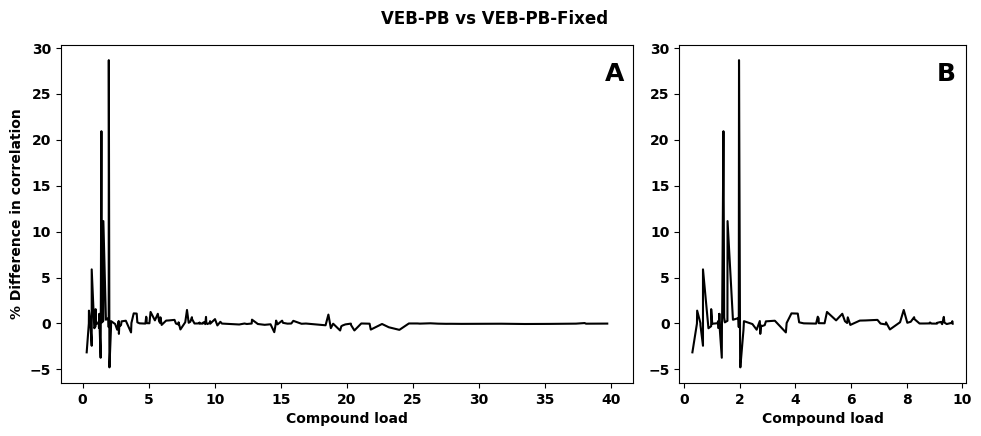

In [285]:
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.5])  


ax = fig.add_subplot(gs[0, 0])
ax.plot(F[idx1],veb_pb_cors[idx1]-veb_pb_fixed_cors[idx1],c="k")
ax.set_ylabel('% Difference in correlation',fontweight="bold")
ax.set_xlabel('Compound load',fontweight="bold")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    
    
ax.text(0.95, 0.95, "A",
        transform=ax.transAxes,        
        fontsize=18, fontweight="bold",
        va="top", ha="left") 

ax = fig.add_subplot(gs[0, 1])
ax.plot(F[idx2],veb_pb_cors[idx2]-veb_pb_fixed_cors[idx2],c="k")
ax.set_xlabel('Compound load',fontweight="bold")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.text(0.90, 0.95, "B",
        transform=ax.transAxes,        
        fontsize=18, fontweight="bold",
        va="top", ha="left") 

plt.suptitle("VEB-PB vs VEB-PB-Fixed", fontweight="bold")
plt.tight_layout()
fig.savefig(REPO_ROOT / "plots" / "veb_pb_vs_veb_pb_fixed.pdf", dpi=300)
plt.show()

In [290]:
np.flip(np.argsort(veb_pb_cors-veb_pb_fixed_cors))

array([ 28,  20,  24,   6,   9,  69,   2,  54,  45,  46,  56,  15, 116,
        50,  84,  72,  59,  21,  26,  51,  73,  90,  99,  25,  63,  55,
        62, 106,  61, 108,  42, 112,  23,  36,  33,  88,  57,  12,  41,
        19,  71,  18,  92,  82,  68,  66,  47,  22,  78,  77,  85, 170,
        70,  87, 180, 109,  81, 186, 179, 187, 188, 185, 178, 183,  44,
        58, 172, 144, 184, 181,  52,   3,  16,  11, 177, 157,  53, 163,
       135, 150, 152,  48, 147, 156, 153,  76, 169, 182, 164, 167, 132,
       133,   1, 126, 166, 168, 160,  74,  75, 100, 111, 162,  96, 155,
       176,  98, 171, 173, 114, 158, 148, 175,  79,  93,  64, 151, 146,
        49, 123,  80, 134, 143, 110, 136, 145, 127, 118,  89, 154, 140,
       159, 174,  10, 161, 113, 165, 138, 137, 149, 139, 142, 105, 129,
       101, 141,  97,  86,  34,  83,  94, 103, 107, 122,  65,  95, 102,
        60, 124,  40, 115,   4,  91,  38, 121,   8, 120,  39,  27, 130,
        13,  14, 117,   7,  67, 128,  35, 131,  32, 125, 119, 10

In [373]:
example_list = []
for i in [28,  20,  24, 17,  29,  30]:
    dct = {"compound":names[i],"load":F[i],"tau":taus[i],"veb_pb_cor":veb_pb_cors[i],"veb_pb_fixed_cor":veb_pb_fixed_cors[i],"wavenumber":wn,"raw_spectrum": raw_spectra[i,:],"veb_pb_correction": veb_pb_c_corrections[i,:],"veb_pb_fixed_correction": veb_pb_fixed_corrections[i,:],"reference_profile":ref_dict[names[i]]}
    example_list.append(dct)
    
with open("../plots/example_list.pkl", "wb") as f:
    pickle.dump(example_list, f)

In [371]:
def plot_example(dct):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    #ax.plot(dct["wavenumber"], dct["raw_spectrum"], label="Raw Spectrum", color="k", alpha=0.5)
    ax.plot(dct["wavenumber"], dct["veb_pb_correction"], label="VEB-PB Correction", color="tab:blue")
    ax.plot(dct["wavenumber"], dct["veb_pb_fixed_correction"], label="VEB-PB-Fixed Correction", color="tab:orange")
    #ax.plot(dct["reference_profile"][:,0], dct["reference_profile"][:,1], label="Reference Profile", color="tab:green", linestyle="--")
    ax.set_title(f"{dct['compound']} - {dct['load']} mg", fontweight="bold")
    ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontweight="bold")
    ax.set_ylabel("Absorbance", fontweight="bold")
    ax.legend()
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")
    plt.tight_layout()
    plt.show()

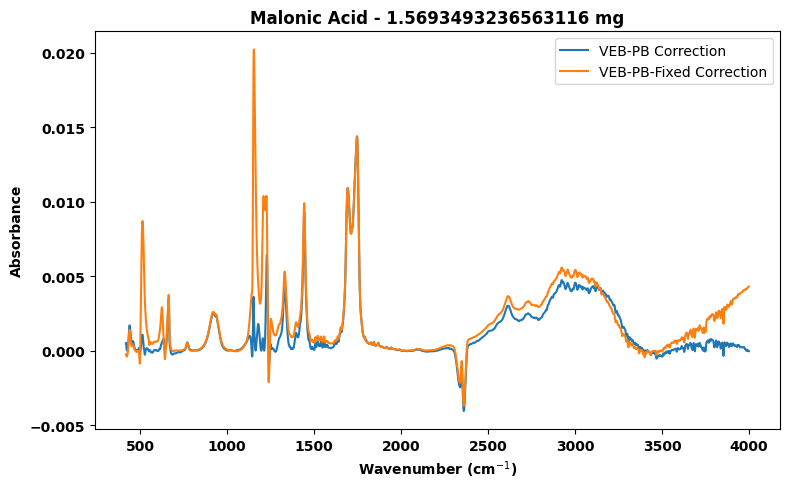

In [372]:
 plot_example(example_list[2])

#### VEB-PB vs VEB-PB-c

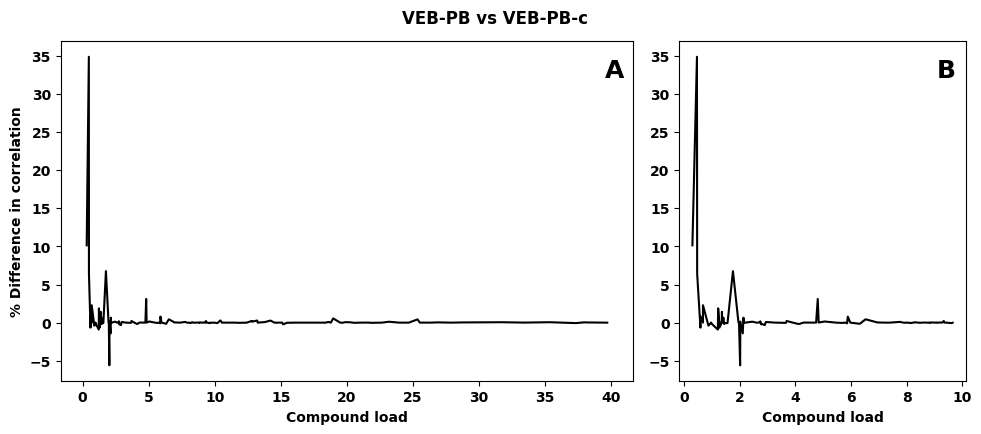

In [287]:
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.5])  


ax = fig.add_subplot(gs[0, 0])
ax.plot(F[idx1],veb_pb_cors[idx1]-veb_pb_c_cors[idx1],c="k")
ax.set_ylabel('% Difference in correlation',fontweight="bold")
ax.set_xlabel('Compound load',fontweight="bold")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")
    
    
ax.text(0.95, 0.95, "A",
        transform=ax.transAxes,        
        fontsize=18, fontweight="bold",
        va="top", ha="left") 

#ax.set_title("VEB-PB vs VEB-PB-Fixed", fontweight="bold",loc="right")

ax = fig.add_subplot(gs[0, 1])
ax.plot(F[idx2],veb_pb_cors[idx2]-veb_pb_c_cors[idx2],c="k")
ax.set_xlabel('Compound load',fontweight="bold")

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.text(0.90, 0.95, "B",
        transform=ax.transAxes,        
        fontsize=18, fontweight="bold",
        va="top", ha="left") 

plt.suptitle("VEB-PB vs VEB-PB-c", fontweight="bold")
plt.tight_layout()
fig.savefig(REPO_ROOT / "plots" / "veb_pb_vs_veb_pb_c.pdf", dpi=300)
plt.show()

In [268]:
taus[28]

np.float64(0.016483923441352456)

np.int64(28)

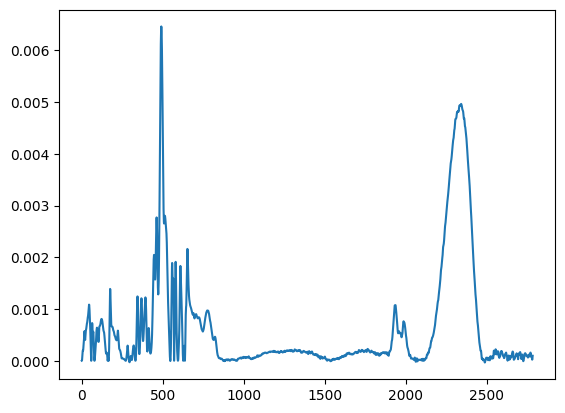

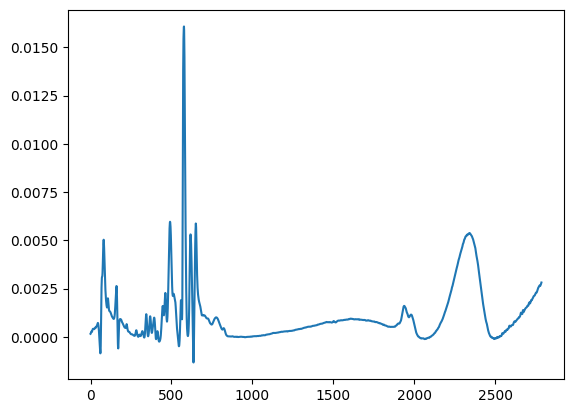

In [264]:
plt.plot(veb_pb_fixed_corrections[28,:])

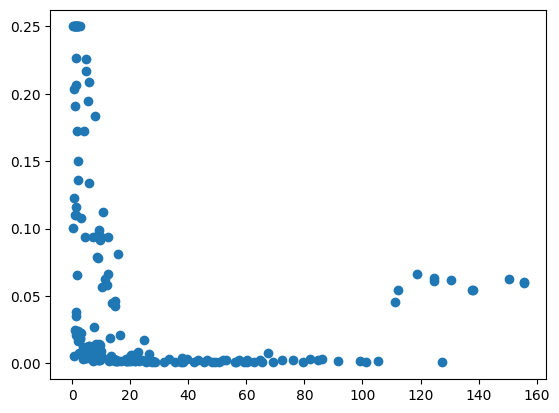

In [272]:
plt.scatter(F,taus)